# Hausse de loyer Équinoxe : notebook de départ

**Votre tâche : estimer la hausse de loyer d'Équinoxe pour 2026.**

Ce notebook vous aide à vous orienter et vous montre une méthode correcte. Les prévisions, les données externes et les décisions de jugement
vous reviennent. Si c'est la première fois que vous utilisez un notebook, pas d'inquiétude. C'est un outil très simple à utiliser et puissant, qui rend les flux de travail clairs et faciles à communiquer. Il est couramment utilisé
en apprentissage profond, et le maîtriser vous aidera énormément si vous vous dirigez un jour vers la science des données ou tout autre domaine analytique. **CTRL/COMMAND + MAJ + H** affiche les raccourcis. Apprenez à supprimer, restaurer, créer et exécuter des cellules. Ça vous aidera.

Lisez les cellules, ne vous contentez pas de les exécuter.

#### Important : vous verrez que la description des données ne correspond pas toujours parfaitement à ce qu'elles sont réellement. Dans ce cas-ci, PromoPay dans les concessions est décrit comme un frais mensuel, ce qui n'est pas du tout le cas. C'est assez facile à comprendre : si la promo égalait le loyer, le résident habiterait en pratique gratuitement.
##### Votre travail consiste aussi à découvrir ce que les données représentent réellement, et à les renommer selon votre propre description. Il n'y a pas de réponse unique.

## 1. Charger les données

## 1b. Lire les colonnes : champs `h` et champs `s`

Chaque colonne de ce jeu commence par **`h`** ou **`s`**. C'est la convention de Yardi, et
se tromper là-dessus est la façon la plus courante de corrompre une requête de gestion immobilière.

| préfixe | signification | exemple | à quoi ça sert |
|---|---|---|---|
| **`h`** | **handle** (identifiant) - une clé numérique | `hUnit`, `hProperty`, `hBuilding` | **les jointures**. Opaque, stable, unique. |
| **`s`** | **stored value** (valeur stockée) - ce qu'un humain lit | `sUnitCode`, `sRent`, `sBuilding` | **l'affichage et le regroupement**. |

Yardi conserve les deux moitiés d'une même information côte à côte - `hAgent` à côté de `sAgent`,
`hProperty` à côté de `sPropCode`. Elles ne sont **pas interchangeables** :

> **Joindre sur `h`. Étiqueter avec `s`.**

Ce n'est pas du pinaillage, c'est tout l'objet de la section 4 ci-dessous. `sUnitCode` vaut `"0203"` - et
trois appartements différents sur un même site portent cette même chaîne. `hUnit` est unique par
construction. Si vous associez une unité à elle-même du côté `s`, vous fusionnez des appartements sans le savoir;
si vous associez sur `hUnit`, c'est impossible.

**Deux mises en garde sur `s`, qui reflètent toutes deux le vrai comportement de Yardi, pas des particularités de ce jeu :**

1. **`s` ne veut pas dire « string ».** La table `UNIT` de Yardi stocke `SRENT` et `DSQFT` comme
   *valeurs numériques*. Ici, `sRent` et `sSqft` sont des nombres. Ne déduisez pas un type d'un préfixe -
   vérifiez-le.
2. **Le vrai Yardi subdivise davantage le côté `s`** - `dt*` pour les dates (`dtLeaseFrom`), `d*`
   pour les doubles (`dSqft`), `i*` pour les entiers, `b*` pour les indicateurs. Ce jeu les ramène tous
   à `s` pour garder l'attention sur la distinction `h` / `s`. Quand vous ouvrirez la vraie base de données, attendez-vous
   à un alphabet plus long.

### Les codes de frais

`sChargeCode` dans le fichier des concessions correspond au plan comptable de Yardi. Les codes semblent abîmés
parce que `sCode` est un `nchar(8)` - « Free other » devient `Freeothe`, « Referencing » devient
`Referenc`. Huit caractères, tronqués, avec une casse incohérente. C'est à ça que ressemblent les vrais.

| `sChargeCode` | `sChargeDesc` | ce que c'est réellement |
|---|---|---|
| `PromoPay` | Promo - Payable in the future | Un rabais promotionnel. **Lisez la mise en garde ci-dessous.** |
| `freerent` | Free rent | Loyer annulé pour une partie du bail. |
| `freepark` | Free Parking | Frais de stationnement annulés. Un avantage *accessoire*, pas du loyer. |
| `freelock` | Free Locker | Casier de rangement offert. Accessoire. |
| `freeappl` | Free Appliances | Frais d'électroménagers annulés. Accessoire. |
| `Freeothe` | Free other | Tout ce qui n'est pas catégorisé. À traiter avec méfiance. |
| `Indem` | Client indemnity | Un paiement versé au résident, par exemple pour régler un différend. |
| `Referenc` | Referencing program | Un crédit de référencement. |

**Celui qu'il faut examiner avant de s'y fier :** `PromoPay` est décrit comme un frais
mensuel. Ce n'en est pas un. Il est très majoritairement inscrit sur un seul mois, pour un montant proche d'un mois
de loyer complet. Prenez la description au pied de la lettre et vous conclurez que les résidents habitent
presque gratuitement. Comparez `sMonths` et la taille de `sAmount` à `sRent` avant de le modéliser -
et décidez vous-même comment l'étaler sur la durée du bail.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

listings   = pd.read_csv("data/equinoxe_listings.csv")
leases     = pd.read_csv("data/equinoxe_lease_history.csv")
concessions= pd.read_csv("data/equinoxe_concessions.csv")
asking     = pd.read_csv("data/equinoxe_asking_history.csv")

for name, df in [("listings", listings), ("leases", leases),
                 ("concessions", concessions), ("asking", asking)]:
    print(f"{name:<12} {len(df):>6,} lignes   {df.shape[1]:>2} colonnes")

listings      1,061 lignes   29 colonnes
leases        4,302 lignes   35 colonnes
concessions   3,560 lignes   18 colonnes
asking        3,857 lignes   14 colonnes


In [2]:
# Convertir les dates une seule fois, dès le départ.
for col in ["sLeaseFrom", "sLeaseTo", "sSignDate", "sAvailable"]:
    if col in leases.columns:
        leases[col] = pd.to_datetime(leases[col], errors="coerce")

leases["year"] = leases.sLeaseFrom.dt.year
asking["date"] = pd.to_datetime(asking.sMonth + "-01")

leases.head(3)

## 2. Ce que vous avez sous les yeux

Six immeubles répartis entre Laval, Mont-Royal, Ottawa et Pointe-Claire. Tout est en date du **2025-12-31**;
il n'y a pas de 2026 dans ce jeu, parce que 2026 est justement ce que vous prédisez.

Cinq sont au Québec et un, The Met, est en Ontario. Ce n'est pas
un détail : les deux provinces encadrent les hausses de loyer selon des régimes différents, et
les traiter comme un seul portefeuille est un choix de modélisation que vous devrez défendre.

**Une chose à bien comprendre avant de commencer.** Il s'agit d'un *extrait publié*, pas du
portefeuille. Il contient une part fixe des unités de chaque immeuble et de chaque type de chambre - la
répartition est représentative, les volumes ne le sont pas. Donc tout ce qui nécessite un dénominateur d'unités
réelles est hors de portée ici : **l'occupation, l'inoccupation, l'absorption et le rôle de loyers total du portefeuille
ne peuvent pas être calculés à partir de ce jeu, et un chiffre que vous en tireriez serait un artefact de
l'extrait plutôt qu'un fait sur l'entreprise.** C'est la *variation* des loyers que ces données permettent de mesurer,
et c'est la variation des loyers qu'on vous demande.

In [3]:
print(listings.groupby(["sState", "sCity", "sBuilding"]).size().to_string())
print()
print(listings.groupby(["sBeds", "sBaths"])
      .agg(units=("sRent", "size"),
           median_rent=("sRent", "median"),
           median_sqft=("sSqft", "median"))
      .to_string())

sState   sCity          sBuilding     
Ontario  Ottawa         The Met           124
Quebec   Laval          Daniel-Johnson    134
                        Levesque           84
                        Saint-Elzear      361
         Mont-Royal     Le Carlyle        192
         Pointe-Claire  Westpark          166

              units  median_rent  median_sqft
sBeds sBaths                                 
0     1.0        49       2565.0        550.0
1     1.0       350       1380.0        600.0
2     1.0       358       2440.0       1150.0
      2.0       281       2605.0       1265.0
3     1.0         2       2687.5       1597.5
      2.0        20       3237.5       1545.0
      3.0         1       4115.0       1905.0


## 3. L'approche évidente

Le premier réflexe naturel : le loyer médian par année.

In [4]:
naive = (leases[leases.year.between(2019, 2025)]
         .groupby("year")
         .agg(leases=("sRent", "size"), median_rent=("sRent", "median")))
naive["yoy_pct"] = (naive.median_rent.pct_change() * 100).round(2)
naive

,leases,median_rent,yoy_pct
year,,,
2019,328,1730.0,NaN
2020,373,1775.0,2.60
2021,361,1850.0,4.23
2022,422,1912.5,3.38
2023,693,2120.0,10.85
2024,902,2215.0,4.48
2025,958,2305.0,4.06


Selon ce tableau, les loyers auraient augmenté de **10,8 % en 2023**. Ce n'est pas le cas.

La médiane bouge dès que la *composition* bouge, et la composition a beaucoup bougé. Plusieurs
immeubles ont été mis en service en 2023 et 2024. Regardez ce qui se passe sous la
médiane :

In [5]:
window = leases[leases.year.between(2019, 2025)]
mix = window.groupby("year").agg(
    leases=("sRent", "size"),
    median_sqft=("sSqft", "median"),
    pct_2bed_plus=("sBeds", lambda s: (s >= 2).mean() * 100),
    buildings=("sBuilding", "nunique"))
mix["rent_per_sqft"] = (window.assign(psf=window.sRent / window.sSqft)
                        .groupby("year").psf.median())
mix.round(2)

,leases,median_sqft,pct_2bed_plus,buildings,rent_per_sqft
year,,,,,
2019,328,1177.5,78.66,3,1.48
2020,373,1180.0,77.75,3,1.53
2021,361,1175.0,78.39,3,1.60
2022,422,1160.0,72.51,3,1.71
2023,693,1095.0,62.63,5,2.04
2024,902,1045.0,62.20,6,2.20
2025,958,1025.0,60.23,6,2.33


In [6]:
# À partir de quand chaque sBuilding a-t-il commencé à générer des baux?
print(window.groupby("sBuilding").year.min().sort_values().to_string())
print()
# Et combien demandent-ils? (baux de 2024)
print(window[window.year == 2024].groupby("sBuilding")
      .agg(leases=("sRent", "size"), median_rent=("sRent", "median"))
      .sort_values("median_rent").to_string())

sBuilding
Daniel-Johnson    2019
Levesque          2019
Saint-Elzear      2019
Le Carlyle        2023
The Met           2023
Westpark          2024

                leases  median_rent
sBuilding                          
Levesque            84       1672.5
Daniel-Johnson     136       1870.0
Saint-Elzear       215       2145.0
Westpark           144       2202.5
Le Carlyle         195       2350.0
The Met            128       2752.5


Les unités louées en 2024 sont **plus petites** que celles louées en 2021 : la superficie
médiane est passée de 1 175 à 1 045 pi², et pourtant le loyer médian a fortement augmenté. C'est
le contraire de ce que la taille seule laisserait prévoir. La part des baux de 2 chambres et plus
est passée de 78 % à 62 % sur la même période.

Ce qui s'est réellement passé : Le Carlyle, The Met et Westpark ont été mis en service en 2023 et 2024. Ce sont des
immeubles haut de gamme, qui louent des unités plus petites, davantage axées sur les 1 chambre, à des tarifs au pied carré
bien plus élevés - la médiane 2024 de The Met est de 2 752 $, contre 1 672 $ pour Lévesque.
Le loyer au pied carré est passé de 1,71 $ à 2,20 $ en deux ans, et presque rien de
cela ne vient d'un locataire existant qui paie plus.


## 4. La méthode qui fonctionne : comparer une unité à elle-même

Associez les baux consécutifs de chaque unité et annualisez la variation. Même appartement,
même immeuble, tout pareil : ce qui reste, c'est le prix.

**La seule chose à ne pas rater :** associez sur `sPropCode` + `sUnitCode`.
Pas sur `sSite` + `sUnitCode`. Plusieurs sites regroupent plus d'un code de propriété avec
des numéros d'unité qui se chevauchent, et **248 des 1 061 unités entrent en collision** si vous utilisez
le site comme clé. Exécutez la cellule suivante pour le constater, puis utilisez `sPropCode` + `sUnitCode`, ou
la colonne `sLink`, qui est construite sur la clé sûre.

In [7]:
# Pourquoi sSite + sUnitCode n'est pas une clé : un site, un numéro d'unité, plusieurs appartements.
# (hUnit est l'identifiant qui EST unique - voir le dictionnaire de données plus haut.)
dupes = listings[listings.duplicated(["sSite", "sUnitCode"], keep=False)]
print(f"{len(dupes):,} unités sur {len(listings):,} entrent en collision sur sSite + sUnitCode")
print()
print(listings[(listings.sSite == "saint-elzear") & (listings.sUnitCode == "0203")]
      [["hUnit", "sSite", "sPropCode", "sUnitCode", "sBeds", "sBaths", "sSqft", "sRent"]]
      .to_string(index=False))

In [8]:
UNIT_KEY = ["sPropCode", "sUnitCode"]      # <-- pas ["sSite", "sUnitCode"]

def same_unit_growth(df, price_col="sRent", date_col="sLeaseFrom",
                     min_gap=0.5, max_gap=2.5):
    """Variation annualisée du loyer, en comparant chaque unité à son propre bail précédent.

    Conserve les écarts entre `min_gap` et `max_gap` années : plus court signifie
    généralement le même bail enregistré deux fois, plus long est trop ancien pour une comparaison équivalente.
    """
    d = df.sort_values(UNIT_KEY + [date_col]).copy()
    d["prev_price"] = d.groupby(UNIT_KEY)[price_col].shift(1)
    d["prev_date"]  = d.groupby(UNIT_KEY)[date_col].shift(1)
    d = d.dropna(subset=["prev_price", "prev_date"])

    d["gap_years"] = (d[date_col] - d.prev_date).dt.days / 365.25
    d = d[d.gap_years.between(min_gap, max_gap, inclusive="neither")]
    d = d[(d.prev_price > 0) & (d[price_col] > 0)]

    d["growth_pct"] = ((d[price_col] / d.prev_price) ** (1 / d.gap_years) - 1) * 100
    return d

pairs = same_unit_growth(leases)
print(f"{len(pairs):,} paires utilisables sur {pairs.groupby(UNIT_KEY).ngroups:,} unités")

honest = (pairs[pairs.year.between(2021, 2025)]
          .groupby("year")
          .growth_pct.agg(pairs="size", median="median").round(2))
honest

3,179 paires utilisables sur 890 unités


,pairs,median
year,,
2021,355,4.46
2022,352,5.40
2023,416,2.29
2024,698,3.39
2025,780,7.04


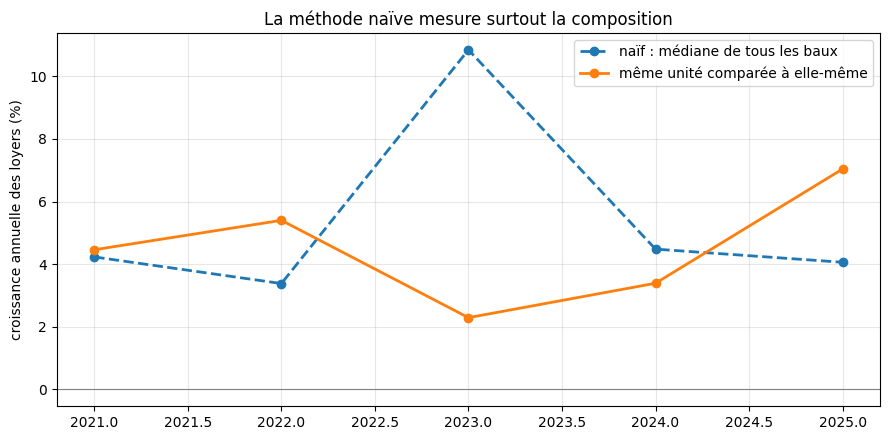

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
yrs = range(2021, 2026)
ax.plot(yrs, naive.loc[yrs, "yoy_pct"], "o--", label="naïf : médiane de tous les baux", lw=2)
ax.plot(yrs, honest.loc[yrs, "median"], "o-", label="même unité comparée à elle-même", lw=2)
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylabel("croissance annuelle des loyers (%)")
ax.set_title("La méthode naïve mesure surtout la composition")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



## 5. Loyer contractuel n'est pas loyer perçu

`sRent` est ce que le bail indique. `sRentEffective` est ce qu'Équinoxe a réellement
perçu après les mois gratuits, le stationnement gratuit et les casiers gratuits. Les concessions sont maintenant
la norme, et elles progressent.

In [10]:
conc = (leases[leases.year.between(2021, 2025)]
        .groupby("year")
        .agg(leases=("sRent", "size"),
             pct_with_concession=("sConcession", lambda s: s.mean() * 100),
             median_contracted=("sRent", "median"),
             median_effective=("sRentEffective", "median")))
conc["gap_pct"] = ((conc.median_effective / conc.median_contracted - 1) * 100)
conc.round(2)

,leases,pct_with_concession,median_contracted,median_effective,gap_pct
year,,,,,
2021,361,54.02,1850.0,1785.00,-3.51
2022,422,57.35,1912.5,1835.00,-4.05
2023,693,54.26,2120.0,2025.40,-4.46
2024,902,73.06,2215.0,2084.46,-5.89
2025,958,85.39,2305.0,2105.59,-8.65


In [11]:
# La concession change-t-elle l'évolution, ou seulement le niveau?
eff = same_unit_growth(leases, price_col="sRentEffective")
compare = pd.DataFrame({
    "contracted": honest["median"],
    "effective":  eff[eff.year.between(2021, 2025)].groupby("year").growth_pct.median(),
}).round(2)
compare

,contracted,effective
year,,
2021,4.46,3.54
2022,5.40,4.59
2023,2.29,2.02
2024,3.39,1.77
2025,7.04,3.58


Ces deux colonnes évoluent de près jusqu'en 2023 - à moins
d'un point l'une de l'autre - puis elles divergent : en 2025, la croissance contractuelle est de
7,0 % alors que la croissance effective est de 3,6 %. L'écart de *niveau* du tableau précédent
se creuse tout au long de la période.

Elles répondent à des questions différentes, et l'année où elles se séparent est celle où les concessions
deviennent plus importantes plutôt que simplement plus fréquentes. Si vous pouvez expliquer ce que cette séparation signifie pour un
propriétaire - et laquelle des deux vous citeriez à un propriétaire - vous comprenez les données
mieux que la plupart des équipes.

## 6. Les renouvellements ne se comportent pas comme les relocations

`sRenewal = 1`, c'est un locataire en place qui renouvelle. `sRenewal = 0`, c'est une unité
qui se libère et qui est relouée au prix du marché. Au Québec, ces deux cas sont régis par
des règles différentes, et l'écart entre les deux est toute la raison pour laquelle un propriétaire s'intéresse
à ce chiffre. Remarquez que l'écart change de camp au cours de la période : les renouvellements mènent en 2022, les relocations en 2025.

In [12]:
split = (pairs[pairs.year.between(2022, 2025)]
         .groupby(["year", "sRenewal"])
         .growth_pct.agg(pairs="size", median="median").round(2)
         .unstack("sRenewal"))
split.columns = [f"{a}_{'renewal' if b else 'turnover'}" for a, b in split.columns]
split

,pairs_turnover,pairs_renewal,median_turnover,median_renewal
year,,,,
2022,126,226,4.22,5.69
2023,177,239,1.85,2.58
2024,276,422,4.85,2.94
2025,307,473,8.98,6.41


## 7. À vous de jouer

Tout ce qui précède est descriptif. Rien de tout ça n'est une prévision, et 2026 n'est pas dans
ce jeu. Ce qui reste, c'est le vrai travail :

**a) Décidez à quelle question vous répondez.** « La hausse de loyer de l'année », ce sont en fait
plusieurs chiffres différents : même unité contractuel, même unité effectif, renouvellements
seulement, relocations seulement, portefeuille combiné. Ils ne concordent pas. Choisissez-en un, nommez-le dans
votre rapport et justifiez votre choix.

**b) Intégrez des données publiques.**

- **Enquête sur les logements locatifs de la SCHL** : loyers et taux d'inoccupation par nombre de chambres pour les
  RMR de Montréal et d'Ottawa, ainsi que la répartition entre logements ayant changé de locataire ou non, qui correspond
  directement à `sRenewal`
- **IPC de Statistique Canada**, composante loyers, Québec et Ontario
- **Tribunal administratif du logement** : les paramètres annuels d'augmentation de loyer au Québec.
  Cinq des six immeubles y sont assujettis
- **Taux légal d'augmentation des loyers en Ontario** : s'applique à l'immeuble The Met, selon
  des règles différentes. N'appliquez pas le plafond d'une province à l'autre

Utilisez la série externe sur l'inoccupation comme *contexte* pour l'orientation des loyers. N'essayez pas
de la transposer en taux d'occupation propre à ce portefeuille - voir la note de la section 2.

**c) Faites une prévision.** Une extrapolation de tendance est un point de départ légitime. Une approche
qui concilie la tendance interne avec le marché externe est meilleure. Énoncez
vos hypothèses.

**e) Misez sur le raisonnement et faites de votre mieux.** Si votre méthode atteint une précision de 95 % et que quelqu'un d'autre obtient 96 %, ça ne veut pas dire que l'autre a gagné. Vous êtes évalué davantage sur la technique que sur le résultat. Les résultats comptent, mais sans un raisonnement constamment démontré derrière chaque choix, même 99 % ne veut rien dire. Nous devons voir une logique claire derrière vos décisions. Note : vous devez **TOUJOURS** expliquer une étape importante, même si ça vous semble inutile ou peu naturel.

### 7a. Chosen Definition
The target we decided to work on is the following:  
Median annualized same-unit effective rent-growth across consecutive leases including renewals and turnovers.  
  
The reasons for that choice are the following:
- Same-unit: Removes the portfolio composition effect (as shown in section 4)
- Effective rent: Reflects the concessions recorded in the dataset
- Median: Reduces sensitivity to extreme lease changes
- Combined renewals and turnovers: Provides one main headline

The year assigned to each observation is the start year of the newer lease. This measures rent growth, not portfolio revenue.

### 7b. Analysis plan

Before forecasting, we measure the selected target consistently from the internal lease history and investigate the factors that may affect it.

We focus on:

- historical same-unit effective-rent growth;
- renewals versus turnovers, including a separate diagnostic for the Quebec portfolio and The Met in Ontario;
- contractual versus effective rent and the role of concessions;
- CMHC rent growth, vacancy and turnover for Montreal and Ottawa;
- annual rent CPI for Quebec and Ontario; and
- same-unit asking-rent growth as a forward-looking check.

### Analysis setup and validation

We create working copies of the lease and concession tables, convert the concession dates and numeric fields, and validate the columns used below. Forecast years and comparison thresholds are defined once as named constants so that the analysis is reproducible and easy to audit.

In [13]:
# Analysis configuration: thresholds and years are named once.
TARGET_PRICE_COL = "sRentEffective"
HISTORY_START_YEAR = 2021
HISTORY_END_YEAR = 2025
FORECAST_YEAR = 2026
BACKTEST_YEARS = [2023, 2024, 2025]
TRAILING_WINDOW_YEARS = 3

# Required starter comparison window.
START_GAP_MIN_YEARS = 0.5
START_GAP_MAX_YEARS = 2.5

# Work on copies so the loaded source tables remain unchanged.
analysis_leases = leases.copy()
analysis_concessions = concessions.copy()

for col in ["sDateFrom", "sDateTo"]:
    analysis_concessions[col] = pd.to_datetime(
        analysis_concessions[col], errors="coerce"
    )
for col in ["sAmount", "sMonths"]:
    analysis_concessions[col] = pd.to_numeric(
        analysis_concessions[col], errors="coerce"
    )

analysis_leases["year"] = analysis_leases["sLeaseFrom"].dt.year

required_lease_cols = [
    "sPropCode", "sUnitCode", "sLeaseFrom", "sLeaseTo",
    "sRent", "sRentEffective", "sRenewal", "sConcession",
]
assert analysis_leases[required_lease_cols].notna().all().all()
assert analysis_leases["sRenewal"].isin([0, 1]).all()
assert analysis_leases["sConcession"].isin([0, 1]).all()
assert not analysis_leases.duplicated(UNIT_KEY + ["sLeaseFrom"]).any()

required_concession_cols = [
    "hUnit", "sDateFrom", "sDateTo", "sAmount", "sMonths"
]
assert analysis_concessions[required_concession_cols].notna().all().all()

print("Basic analysis-data checks passed.")

Basic analysis-data checks passed.


### Historical target
We first apply the selected definition consistently to each historical year.

In [14]:
target_pairs = same_unit_growth(
    analysis_leases,
    price_col=TARGET_PRICE_COL,
    min_gap=START_GAP_MIN_YEARS,
    max_gap=START_GAP_MAX_YEARS,
)

target_history = (
    target_pairs[
        target_pairs["year"].between(
            HISTORY_START_YEAR,
            HISTORY_END_YEAR
        )
    ]
    .groupby("year")["growth_pct"]
    .agg(pairs="size", median_growth_pct="median")
)

display(target_history.round(2))

,pairs,median_growth_pct
year,,
2021,355,3.54
2022,352,4.59
2023,416,2.02
2024,698,1.77
2025,780,3.58


In [15]:
def historical_target(lease_data):
    """Return yearly median same-unit effective-rent growth."""
    pairs = same_unit_growth(
        lease_data,
        price_col=TARGET_PRICE_COL,
        min_gap=START_GAP_MIN_YEARS,
        max_gap=START_GAP_MAX_YEARS,
    )

    return (
        pairs.groupby("year")["growth_pct"]
        .median()
        .sort_index()
    )

Same-unit effective growth declines in 2023 and 2024 before rebounding in 2025. The samplse become larger from 2023 onward, so the recent estimates are based on more matched pairs.

#### Renewals and turnovers

In [16]:
target_by_lease_type = (
    target_pairs[
        target_pairs["year"].between(
            HISTORY_START_YEAR,
            HISTORY_END_YEAR,
        )
    ]
    .assign(
        lease_type=lambda d: d["sRenewal"].map({
            0: "turnover",
            1: "renewal",
        })
    )
    .groupby(["year", "lease_type"])["growth_pct"]
    .agg(pairs="size", median_growth_pct="median")
)

display(target_by_lease_type.round(2))

pairs  median_growth_pct
year lease_type                          
2021 renewal       220               4.00
     turnover      135               2.36
2022 renewal       226               4.92
     turnover      126               3.40
2023 renewal       239               2.21
     turnover      177               1.68
2024 renewal       422               1.38
     turnover      276               2.75
2025 renewal       473               2.91
     turnover      307               5.74

Renewals have higher median effective-rent growth in 2021-2023. The relationship reverses in 2024-2025, when turnover growth exceeds renewal growth. 

#### Quebec and The Met by lease type

The following diagnostic separates the Quebec portfolio from The Met in Ontario, and renewals from turnovers.

In [17]:
unit_regimes = (
    listings[["sPropCode", "sUnitCode", "sState"]]
    .drop_duplicates()
    .copy()
)

unit_regimes["regime"] = np.where(
    unit_regimes["sState"].eq("Ontario"),
    "The Met / Ontario",
    "Quebec portfolio",
)

regime_pairs = target_pairs.merge(
    unit_regimes[["sPropCode", "sUnitCode", "regime"]],
    on=["sPropCode", "sUnitCode"],
    how="left",
    validate="many_to_one",
)
assert regime_pairs["regime"].notna().all()

regime_pairs["lease_type"] = regime_pairs["sRenewal"].map({
    0: "turnover",
    1: "renewal",
})

regime_by_lease_type = (
    regime_pairs[
        regime_pairs["year"].between(
            HISTORY_START_YEAR,
            HISTORY_END_YEAR,
        )
    ]
    .groupby(["year", "regime", "lease_type"])["growth_pct"]
    .agg(pairs="size", median_growth_pct="median")
)

display(regime_by_lease_type.round(2))

pairs  median_growth_pct
year regime            lease_type                          
2021 Quebec portfolio  renewal       220               4.00
                       turnover      135               2.36
2022 Quebec portfolio  renewal       226               4.92
                       turnover      126               3.40
2023 Quebec portfolio  renewal       239               2.21
                       turnover      177               1.68
2024 Quebec portfolio  renewal       355               1.40
                       turnover      235               2.52
     The Met / Ontario renewal        67               1.33
                       turnover       41               3.21
2025 Quebec portfolio  renewal       410               2.97
                       turnover      253               5.80
     The Met / Ontario renewal        63               2.46
                       turnover       54               5.45

The Quebec portfolio drives the historical headline because The Met has eligible same-unit pairs only in 2024 and 2025. In both regimes, turnover growth exceeds renewal growth in those two years. The Ontario samples are useful diagnostics but too short to support a separate three-year forecast, so we retain the combined portfolio baseline and interpret The Met separately.

#### Effective vs Contractual

In [18]:
contractual_pairs = same_unit_growth(
    analysis_leases,
    price_col="sRent",
    min_gap=START_GAP_MIN_YEARS,
    max_gap=START_GAP_MAX_YEARS,
)

pair_key = UNIT_KEY + ["sLeaseFrom"]

comparison_pairs = target_pairs.merge(
    contractual_pairs[
        pair_key + ["growth_pct"]
    ].rename(
        columns={"growth_pct": "contractual_growth_pct"}
    ),
    on=pair_key,
    how="inner",
    validate="one_to_one",
)

rent_type_comparison = (
    comparison_pairs[
        comparison_pairs["year"].between(
            HISTORY_START_YEAR,
            HISTORY_END_YEAR
        )
    ]
    .assign(
        lease_type=lambda d:
        d["sRenewal"].map({
            0: "turnover",
            1: "renewal",
        })
    )
    .groupby(["year", "lease_type"])
    .agg(
        pairs=("growth_pct", "size"),
        contractual_growth_pct=(
            "contractual_growth_pct",
            "median",
        ),
        effective_growth_pct=(
            "growth_pct",
            "median",
        ),
    )
)

display(rent_type_comparison.round(2))

pairs  contractual_growth_pct  effective_growth_pct
year lease_type                                                     
2021 renewal       220                    4.77                  4.00
     turnover      135                    3.52                  2.36
2022 renewal       226                    5.69                  4.92
     turnover      126                    4.22                  3.40
2023 renewal       239                    2.58                  2.21
     turnover      177                    1.85                  1.68
2024 renewal       422                    2.94                  1.38
     turnover      276                    4.85                  2.75
2025 renewal       473                    6.41                  2.91
     turnover      307                    8.98                  5.74

Contractual and effective growth move in the same direction, but their gap widens in 2024-2025 for both lease types. The widening gap indicates that larger concessions reduce realized effective-rent growth, especially when turnover growth accelerates.

#### Understanding the concession data

In [19]:
analysis_concessions["date_span_days"] = (
    analysis_concessions["sDateTo"]
    - analysis_concessions["sDateFrom"]
).dt.days

concession_summary = (
    analysis_concessions
    .groupby(
        ["sChargeCode", "sChargeDesc"],
        dropna=False
    )
    .agg(
        records=("hUnit", "size"),
        units=("hUnit", "nunique"),
        median_amount=("sAmount", "median"),
        median_months=("sMonths", "median"),
        median_span_days=("date_span_days", "median"),
    )
    .sort_values("records", ascending=False)
)

display(concession_summary.round(2))

,,records,units,median_amount,median_months,median_span_days
sChargeCode,sChargeDesc,,,,,
PromoPay,Promo - Payable in the future,1494,781,-1356.60,1.0,29.0
freepark,Free Parking,1006,646,-150.50,12.0,364.0
Freeothe,Free other,570,436,-153.49,12.0,364.0
freelock,Free Locker,175,166,-139.35,12.0,364.0
freerent,Free rent,166,152,-129.30,12.0,364.0
Indem,Client indemnity,69,66,-149.26,12.0,364.0
freeappl,Free Appliances,44,39,-143.58,12.0,364.0
Referenc,Referencing program,36,35,-148.26,12.0,364.0


All recorded concession amounts are negative. PromoPay is the clear timing outlier: its median record covers one month and about 29 days, whereas every other charge-code group has a median of 12 months and about 364 days. We therefore treat PromoPay as a one-time credit rather than a recurring monthly discount; the forecast itself uses the already supplied `sRentEffective` field.

#### Linking concessions to leases

To audit whether concession records can be associated with a lease, we assign a concession when its start date falls within the lease period. We use the start date rather than general interval overlap because most non-PromoPay records span 12 months and can otherwise overlap adjacent leases. This linkage is a validation step only; the forecast uses `sRentEffective` directly.


In [20]:
concession_candidates = (
    analysis_concessions[["hUnit", "sDateFrom"]]
    .reset_index()
    .rename(columns={"index": "concession_id"})
    .merge(
        analysis_leases[["hUnit", "sLeaseFrom", "sLeaseTo"]],
        on="hUnit",
        how="left",
    )
)

starts_within_lease = concession_candidates["sDateFrom"].between(
    concession_candidates["sLeaseFrom"],
    concession_candidates["sLeaseTo"],
    inclusive="both",
)

match_counts = (
    concession_candidates.loc[starts_within_lease]
    .groupby("concession_id")
    .size()
    .reindex(analysis_concessions.index, fill_value=0)
)

match_summary = pd.Series({
    "No matching lease": match_counts.eq(0).sum(),
    "Exactly one matching lease": match_counts.eq(1).sum(),
    "Multiple matching leases": match_counts.gt(1).sum(),
})

display(match_summary.to_frame("concessions"))
print(f"Unique-match rate: {match_counts.eq(1).mean():.2%}")

,concessions
No matching lease,204
Exactly one matching lease,3356
Multiple matching leases,0


Unique-match rate: 94.27%


Of the 3,560 concession records, **3,356 (94.27%)** match exactly one lease, 204 do not match a lease using this rule, and none match multiple leases.

#### Concession trends over time

In [21]:
concession_trend = analysis_leases.copy()

concession_trend["rent_discount"] = (
    concession_trend["sRent"]
    - concession_trend["sRentEffective"]
)

trend_window = concession_trend[
    concession_trend["year"].between(
        HISTORY_START_YEAR,
        HISTORY_END_YEAR,
    )
].copy()

yearly_concessions = (
    trend_window
    .groupby("year")
    .agg(
        leases=("hUnit", "size"),
        concession_rate_pct=(
            "sConcession",
            "mean",
        ),
        median_discount=(
            "rent_discount",
            "median",
        ),
    )
)

yearly_concessions[
    "concession_rate_pct"
] *= 100

display(yearly_concessions.round(2))

,leases,concession_rate_pct,median_discount
year,,,
2021,361,54.02,48.40
2022,422,57.35,69.72
2023,693,54.26,71.23
2024,902,73.06,134.67
2025,958,85.39,219.92


Concessions become both more common and economically larger. Their prevalence rises from 54.02% of observed leases in 2021 to 85.39% in 2025. The median contractual-to-effective rent difference increases from CAD 48.40 per month to CAD 219.92 per month.

#### External market context

CMHC provides CMA-level measures for Montreal and Ottawa. We extract three simple "Total" series from the supplied workbooks: average-rent growth, vacancy and turnover. We also add Statistics Canada's annual-average rent CPI for Quebec and Ontario. These indicators describe the surrounding market; they are not portfolio occupancy measures and are not fitted forecast inputs.

In [22]:
from pathlib import Path
import re

EXTERNAL_DATA_DIR = Path("external_data")
CMHC_TABLES = {
    "cmhc_rent_growth_pct": "Table 1.1.5",
    "cmhc_vacancy_pct": "Table 1.1.1",
    "cmhc_turnover_pct": "Table 1.1.6",
}


def extract_cmhc_total(filepath, cma_name, sheet_name, value_name):
    """Extract the two CMA Total observations from one CMHC table."""
    report_match = re.search(r"(20\d{2})", filepath.name)
    if not report_match:
        raise ValueError(f"Could not determine report year from {filepath.name}")
    report_year = int(report_match.group(1))

    table = pd.read_excel(filepath, sheet_name=sheet_name, header=None)
    total_cells = np.argwhere(table.eq("Total").to_numpy())
    if len(total_cells) == 0:
        raise ValueError(f"{filepath.name} {sheet_name}: Total not found")
    total_header_row, total_start_col = total_cells[0]

    period_columns = []
    for row_index in range(total_header_row + 1, table.shape[0]):
        candidates = []
        for column_index in range(total_start_col, table.shape[1]):
            label = str(table.iat[row_index, column_index]).replace("\n", " ")
            years = re.findall(r"Oct-(\d{2})", label, flags=re.IGNORECASE)
            if years:
                candidates.append((column_index, 2000 + int(years[-1])))
        if candidates:
            period_columns = candidates
            break

    if len(period_columns) != 2:
        raise ValueError(
            f"{filepath.name} {sheet_name}: expected two Total periods, "
            f"found {len(period_columns)}"
        )

    geography = table.iloc[:, 0].astype(str).str.strip()
    cma_rows = table.loc[geography.eq(cma_name)]
    if len(cma_rows) != 1:
        raise ValueError(
            f"{filepath.name} {sheet_name}: expected one {cma_name!r} row, "
            f"found {len(cma_rows)}"
        )
    cma_row = cma_rows.iloc[0]

    observations = []
    for column_index, year in period_columns:
        value = pd.to_numeric(cma_row.iloc[column_index], errors="coerce")
        if pd.isna(value):
            raise ValueError(
                f"{filepath.name} {sheet_name}: non-numeric Total value"
            )
        observations.append({
            "market": cma_name,
            "year": year,
            value_name: float(value),
            "source_report": report_year,
        })

    return pd.DataFrame(observations)


market_files = {
    "montreal": "Montréal CMA",
    "ottawa": "Ottawa CMA",
}
external_results = []

for filename_market, cma_name in market_files.items():
    files = sorted(
        EXTERNAL_DATA_DIR.glob(f"rmr-{filename_market}-*-en.xlsx")
    )
    if not files:
        raise FileNotFoundError(
            f"No CMHC workbooks found for {filename_market}"
        )

    for filepath in files:
        report_data = None
        for value_name, sheet_name in CMHC_TABLES.items():
            measure = extract_cmhc_total(
                filepath,
                cma_name,
                sheet_name,
                value_name,
            )
            if report_data is None:
                report_data = measure
            else:
                report_data = report_data.merge(
                    measure,
                    on=["market", "year", "source_report"],
                    how="outer",
                    validate="one_to_one",
                )
        external_results.append(report_data)

cmhc_external = (
    pd.concat(external_results, ignore_index=True)
    .sort_values("source_report")
    .drop_duplicates(["market", "year"], keep="last")
    .loc[lambda d: d["year"].between(
        HISTORY_START_YEAR,
        HISTORY_END_YEAR,
    )]
    .sort_values(["market", "year"])
    .reset_index(drop=True)
)

cmhc_measure_cols = list(CMHC_TABLES)
assert cmhc_external[cmhc_measure_cols].notna().all().all()
display(cmhc_external.round(2))

,market,year,cmhc_rent_growth_pct,source_report,cmhc_vacancy_pct,cmhc_turnover_pct
0,Montréal CMA,2021,3.7,2022,3.0,11.4
1,Montréal CMA,2022,5.1,2023,2.0,10.3
2,Montréal CMA,2023,7.7,2024,1.5,9.6
3,Montréal CMA,2024,6.4,2025,2.1,11.1
4,Montréal CMA,2025,7.4,2025,2.9,9.4
5,Ottawa CMA,2021,2.2,2022,3.4,22.8
6,Ottawa CMA,2022,3.9,2023,2.1,16.7
7,Ottawa CMA,2023,4.3,2024,2.1,16.5
8,Ottawa CMA,2024,5.2,2025,2.6,14.5
9,Ottawa CMA,2025,3.5,2025,3.0,15.4


#### Rent CPI by province

To keep the notebook reproducible without an internet connection, the small table below records the official annual-average rent CPI indexes for Quebec and Ontario. Growth is calculated in the notebook rather than entered manually.

In [23]:
# Statistics Canada Table 18-10-0005-01, annual average, 2002=100.
rent_cpi_index = pd.DataFrame({
    "year": [2020, 2021, 2022, 2023, 2024, 2025],
    "Quebec": [122.7, 126.0, 130.6, 138.2, 150.5, 162.2],
    "Ontario": [126.7, 128.6, 135.7, 144.2, 154.2, 160.8],
})

rent_cpi = rent_cpi_index.melt(
    id_vars="year",
    var_name="province",
    value_name="rent_cpi_index",
).sort_values(["province", "year"])

rent_cpi["rent_cpi_growth_pct"] = (
    rent_cpi.groupby("province")["rent_cpi_index"]
    .pct_change()
    .mul(100)
)
rent_cpi["market"] = rent_cpi["province"].map({
    "Quebec": "Montréal CMA",
    "Ontario": "Ottawa CMA",
})
rent_cpi = rent_cpi[
    rent_cpi["year"].between(
        HISTORY_START_YEAR,
        HISTORY_END_YEAR,
    )
].reset_index(drop=True)

display(rent_cpi.round(2))

,year,province,rent_cpi_index,rent_cpi_growth_pct,market
0,2021,Ontario,128.6,1.50,Ottawa CMA
1,2022,Ontario,135.7,5.52,Ottawa CMA
2,2023,Ontario,144.2,6.26,Ottawa CMA
3,2024,Ontario,154.2,6.93,Ottawa CMA
4,2025,Ontario,160.8,4.28,Ottawa CMA
5,2021,Quebec,126.0,2.69,Montréal CMA
6,2022,Quebec,130.6,3.65,Montréal CMA
7,2023,Quebec,138.2,5.82,Montréal CMA
8,2024,Quebec,150.5,8.90,Montréal CMA
9,2025,Quebec,162.2,7.77,Montréal CMA


In [24]:
unit_markets = (
    listings[["sPropCode", "sUnitCode", "sState"]]
    .drop_duplicates()
    .copy()
)

unit_markets["market"] = np.where(
    unit_markets["sState"].eq("Ontario"),
    "Ottawa CMA",
    "Montréal CMA",
)

market_pairs = same_unit_growth(
    leases,
    price_col=TARGET_PRICE_COL,
    min_gap=START_GAP_MIN_YEARS,
    max_gap=START_GAP_MAX_YEARS,
).merge(
    unit_markets[["sPropCode", "sUnitCode", "market"]],
    on=["sPropCode", "sUnitCode"],
    how="left",
    validate="many_to_one",
)

jadco_by_market = (
    market_pairs[
        market_pairs["year"].between(
            HISTORY_START_YEAR,
            HISTORY_END_YEAR,
        )
    ]
    .groupby(["market", "year"])["growth_pct"]
    .median()
    .rename("jadco_growth_pct")
    .reset_index()
)

market_external_comparison = (
    jadco_by_market
    .merge(
        cmhc_external.drop(columns="source_report"),
        on=["market", "year"],
        how="left",
        validate="one_to_one",
    )
    .merge(
        rent_cpi[["market", "year", "rent_cpi_growth_pct"]],
        on=["market", "year"],
        how="left",
        validate="one_to_one",
    )
)

external_cols = [
    "cmhc_rent_growth_pct",
    "cmhc_vacancy_pct",
    "cmhc_turnover_pct",
    "rent_cpi_growth_pct",
]
assert market_external_comparison[external_cols].notna().all().all()
display(market_external_comparison.round(2))

,market,year,jadco_growth_pct,cmhc_rent_growth_pct,cmhc_vacancy_pct,cmhc_turnover_pct,rent_cpi_growth_pct
0,Montréal CMA,2021,3.54,3.7,3.0,11.4,2.69
1,Montréal CMA,2022,4.59,5.1,2.0,10.3,3.65
2,Montréal CMA,2023,2.02,7.7,1.5,9.6,5.82
3,Montréal CMA,2024,1.75,6.4,2.1,11.1,8.90
4,Montréal CMA,2025,3.64,7.4,2.9,9.4,7.77
5,Ottawa CMA,2024,1.89,5.2,2.6,14.5,6.93
6,Ottawa CMA,2025,3.39,3.5,3.0,15.4,4.28


Montreal's CMHC rent growth and Quebec rent CPI exceed Collection Equinoxe's same-unit effective growth from 2023 onward. At the same time, Montreal vacancy rises from 1.5% in 2023 to 2.9% in 2025, indicating that strong published rent growth coexists with a market that is becoming less tight. This supports using the external series as context rather than copying its growth rate into the forecast.

Ottawa is available internally only in 2024-2025. In 2025, The Met's same-unit effective growth is close to CMHC Ottawa rent growth, while Ottawa vacancy and turnover both rise modestly. Ontario rent CPI also slows in 2025. Together, the indicators support separate interpretation for The Met but not a stand-alone three-year forecast from the limited internal history.

#### Same-unit asking-rent check

Asking history is sparse and records listing events rather than a complete monthly panel. We therefore take one median asking rent per unit-year, compare it with the same unit's previous observed year, and retain one- or two-year gaps. This is a forward-looking check, not the forecast target.

In [25]:
asking_unit_year = (
    asking.assign(year=asking["date"].dt.year)
    .groupby(UNIT_KEY + ["year"], as_index=False)["sAskingRent"]
    .median()
    .sort_values(UNIT_KEY + ["year"])
)

asking_unit_year["prev_asking_rent"] = (
    asking_unit_year.groupby(UNIT_KEY)["sAskingRent"].shift(1)
)
asking_unit_year["prev_year"] = (
    asking_unit_year.groupby(UNIT_KEY)["year"].shift(1)
)
asking_unit_year["gap_years"] = (
    asking_unit_year["year"] - asking_unit_year["prev_year"]
)

asking_pairs = asking_unit_year[
    asking_unit_year["gap_years"].between(1, 2)
    & asking_unit_year["prev_asking_rent"].gt(0)
    & asking_unit_year["sAskingRent"].gt(0)
].copy()
asking_pairs["asking_growth_pct"] = (
    (
        asking_pairs["sAskingRent"]
        / asking_pairs["prev_asking_rent"]
    ) ** (1 / asking_pairs["gap_years"])
    - 1
) * 100

asking_history = (
    asking_pairs[
        asking_pairs["year"].between(
            HISTORY_START_YEAR,
            HISTORY_END_YEAR,
        )
    ]
    .groupby("year")["asking_growth_pct"]
    .agg(asking_pairs="size", asking_growth_pct="median")
)

asking_vs_effective = (
    target_history.rename(columns={
        "pairs": "effective_pairs",
        "median_growth_pct": "effective_growth_pct",
    })
    .join(asking_history, how="left")
)

display(asking_vs_effective.round(2))

,effective_pairs,effective_growth_pct,asking_pairs,asking_growth_pct
year,,,,
2021,355,3.54,206,3.76
2022,352,4.59,203,4.44
2023,416,2.02,265,2.86
2024,698,1.77,404,3.78
2025,780,3.58,462,7.14


Asking and effective growth are reasonably close through 2023, then diverge: median same-unit asking growth reaches 3.78% in 2024 and 7.14% in 2025, compared with effective growth of 1.77% and 3.58%. This suggests continued pricing ambition, but also shows why asking rent should not replace realized effective rent when concessions are large.

### 7c. Forecast baseline selection

In [26]:
history = historical_target(analysis_leases)

baseline_rows = []

for target_year in BACKTEST_YEARS:
    actual = float(history.loc[target_year])

    persistence_prediction = float(
        history.loc[target_year - 1]
    )

    trailing_years = list(
        range(
            target_year - TRAILING_WINDOW_YEARS,
            target_year
        )
    )

    trailing_prediction = float(
        history.reindex(trailing_years).mean()
    )

    baseline_rows.append({
        "year": target_year,
        "actual_pct": actual,
        "persistence_pct": persistence_prediction,
        "trailing_3y_pct": trailing_prediction,
    })

baseline_comparison = (
    pd.DataFrame(baseline_rows)
    .set_index("year")
)

baseline_comparison["persistence_abs_error"] = (
    baseline_comparison["persistence_pct"]
    - baseline_comparison["actual_pct"]
).abs()

baseline_comparison["trailing_3y_abs_error"] = (
    baseline_comparison["trailing_3y_pct"]
    - baseline_comparison["actual_pct"]
).abs()

display(baseline_comparison.round(2))

persistence_mae = (
    baseline_comparison["persistence_abs_error"].mean()
)

trailing_mae = (
    baseline_comparison["trailing_3y_abs_error"].mean()
)

print(f"Persistence MAE: {persistence_mae:.2f} pp")
print(f"Three-year trailing mean MAE: {trailing_mae:.2f} pp")

,actual_pct,persistence_pct,trailing_3y_pct,persistence_abs_error,trailing_3y_abs_error
year,,,,,
2023,2.02,4.59,3.72,2.57,1.70
2024,1.77,2.02,3.38,0.25,1.61
2025,3.58,1.77,2.79,1.80,0.78


Persistence MAE: 1.54 pp
Three-year trailing mean MAE: 1.36 pp


The three-year trailing mean performs slightly better than persistence across the available backtest years, with a mean absolute error of  **1.36 percentage points** versus **1.54 percentage points** for persistence.

The difference is modest and only three historical backtest years are available, so this should not be interpreted as strong evidence that the trailing mean is universally superior.

It provides the best-performing simple baseline and is therefore selected as the central forecasting method.

#### Regulatory context

In [27]:
# Official 2026 values; see References for scope and sources.
TAL_BASE_PERCENTAGE_QUEBEC_2026 = 3.1
ONTARIO_RENT_INCREASE_GUIDELINE_2026 = 2.1

regulatory_context_2026 = pd.DataFrame({
    "market": ["Montréal CMA", "Ottawa CMA"],
    "measure": [
        "Quebec TAL base percentage",
        "Ontario rent increase guideline",
    ],
    "value_pct": [
        TAL_BASE_PERCENTAGE_QUEBEC_2026,
        ONTARIO_RENT_INCREASE_GUIDELINE_2026,
    ],
    "scope": [
        "Base component; not a universal cap or direct forecast",
        "Most rent-controlled renewals; not turnover; exemptions apply",
    ],
})

display(regulatory_context_2026)

,market,measure,value_pct,scope
0,Montréal CMA,Quebec TAL base percentage,3.1,Base component; not a universal cap or direct ...
1,Ottawa CMA,Ontario rent increase guideline,2.1,Most rent-controlled renewals; not turnover; e...


The Quebec value is the TAL base percentage for applicable 2026 notices; it is not a universal cap and each dwelling-specific calculation may differ. Ontario's 2.1% guideline applies to most rent-controlled renewals, not to turnover rents, and buildings first occupied for residential purposes after November 15, 2018 are generally exempt.

The Met was first occupied in 2022, so it is generally exempt from the Ontario guideline. Occupancy records should be kept to support that conclusion. Both regulatory values are therefore retained as interpretation context rather than blended mechanically into the portfolio forecast.

### 7d. Forecast implementation and backtest

The selected baseline uses only information available before each target year. It averages the previous three annual values of the same-unit effective-rent target, then compares that prediction with the realized target. `trailing_mean_forecast()` stays as a separate helper because both `estimate_2026()` and `backtest()` use the same logic. The required function interface retains `asking` and `external`, but this simple baseline does not use them as numerical inputs.

In [28]:
# Shared helper: estimate_2026() and backtest() use the same forecast logic.

def trailing_mean_forecast(
    lease_data,
    target_year,
    window=TRAILING_WINDOW_YEARS,
):
    """Forecast from the preceding `window` yearly headline values."""
    cutoff = pd.Timestamp(target_year, 1, 1)
    available_leases = lease_data.loc[
        lease_data["sLeaseFrom"] < cutoff
    ].copy()

    history = historical_target(available_leases)
    required_years = list(range(target_year - window, target_year))
    recent_history = history.reindex(required_years)

    if recent_history.isna().any():
        raise ValueError(
            f"Missing historical target values required "
            f"to forecast {target_year}."
        )

    return float(recent_history.mean())


def estimate_2026(leases, asking, external=None):
    """Return the 2026 rent-growth estimate as a percentage."""
    return trailing_mean_forecast(
        leases,
        target_year=FORECAST_YEAR,
    )


def backtest(leases, target_year):
    """Prévoit target_year avec les années antérieures et compare au réalisé."""
    prediction = trailing_mean_forecast(
        leases,
        target_year=target_year,
    )

    actual_history = historical_target(leases)
    if target_year not in actual_history.index:
        raise ValueError(
            f"No realized target available for {target_year}."
        )

    actual = float(actual_history.loc[target_year])
    return {
        "year": target_year,
        "prediction_pct": prediction,
        "actual_pct": actual,
        "error_pp": prediction - actual,
        "absolute_error_pp": abs(prediction - actual),
    }

In [29]:
backtest_results = pd.DataFrame(
    [
        backtest(leases, year)
        for year in BACKTEST_YEARS
    ]
).set_index("year")

backtest_mae = (
    backtest_results["absolute_error_pp"].mean()
)

final_estimate = estimate_2026(
    leases,
    asking,
    external=cmhc_external,
)
forecast_low = final_estimate - backtest_mae
forecast_high = final_estimate + backtest_mae

display(backtest_results.round(2))

print(
    f"Backtest MAE: {backtest_mae:.2f} "
    "percentage points"
)

print(
    f"2026 estimate: {final_estimate:.2f}%"
)

print(
    f"Planning range: {forecast_low:.2f}% to "
    f"{forecast_high:.2f}%"
)

,prediction_pct,actual_pct,error_pp,absolute_error_pp
year,,,,
2023,3.72,2.02,1.70,1.70
2024,3.38,1.77,1.61,1.61
2025,2.79,3.58,-0.78,0.78


Backtest MAE: 1.36 percentage points
2026 estimate: 2.46%
Planning range: 1.09% to 3.82%


### 7e. Final 2026 forecast

Our current estimate for Collection Equinoxe's 2026 rent increase is:

**2.46% median annualized same-unit effective-rent growth.**

For planning, we use a simple range of **1.09% to 3.82%**. This is the 2.46% estimate plus or minus the backtest MAE using the unrounded values. It is a planning range, not a confidence interval.

The estimate is the mean of the previous three yearly headline observations. It assumes that recent same-unit effective growth remains informative for 2026, gives each historical year equal weight, and retains the observed mix of eligible renewals and turnovers.

This baseline achieved a mean absolute backtest error of approximately **1.36 percentage points** across 2023, 2024, and 2025, slightly outperforming one-year persistence. Contractual and effective growth diverge substantially in 2024-2025 as concessions become both more frequent and economically larger.

The additional diagnostics do not replace the target. The Met has only two years of eligible internal comparisons, so Quebec and Ontario are interpreted separately but not assigned separate forecasts. CMHC rent growth, vacancy, turnover and provincial rent CPI confirm market pressure while also showing some easing in vacancy and Ontario inflation. Same-unit asking growth reaches 7.14% in 2025, but realized effective growth is only 3.58%, reinforcing the decision not to use asking rent mechanically.

The final approach remains simple and reproducible: external and asking indicators challenge the 2.46% internal baseline, but are not fitted inputs. They provide context instead of an arbitrary blended adjustment.

### 7f. Final forecast and backtest chart

The solid line shows the realized target for each backtest year. The dashed line shows the three-year trailing-mean prediction made using only earlier data, extended to the 2026 forecast. Grey segments show the historical errors, and the 2026 whisker shows the planning range based on the backtest MAE.

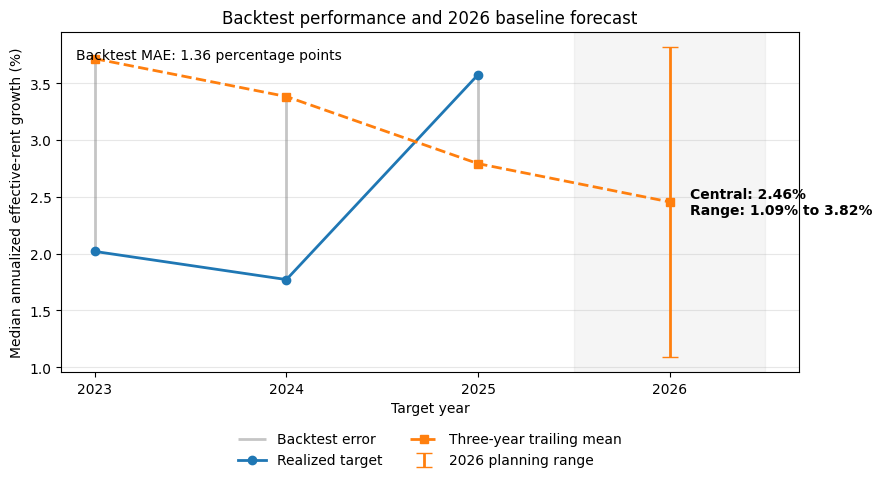

In [30]:
chart_years = BACKTEST_YEARS + [FORECAST_YEAR]
chart_predictions = pd.Series(
    [
        *backtest_results["prediction_pct"].tolist(),
        final_estimate,
    ],
    index=chart_years,
)
chart_actuals = backtest_results["actual_pct"]

fig, ax = plt.subplots(figsize=(9, 5))

ax.vlines(
    BACKTEST_YEARS,
    chart_actuals,
    chart_predictions.loc[BACKTEST_YEARS],
    color="grey",
    alpha=0.45,
    linewidth=2,
    label="Backtest error",
)
ax.plot(
    BACKTEST_YEARS,
    chart_actuals,
    marker="o",
    linewidth=2,
    label="Realized target",
)
ax.plot(
    chart_years,
    chart_predictions,
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Three-year trailing mean",
)
ax.errorbar(
    FORECAST_YEAR,
    final_estimate,
    yerr=backtest_mae,
    fmt="none",
    color="tab:orange",
    capsize=6,
    linewidth=2,
    label="2026 planning range",
)

ax.axvspan(
    FORECAST_YEAR - 0.5,
    FORECAST_YEAR + 0.5,
    color="grey",
    alpha=0.08,
)
ax.annotate(
    (
        f"Central: {final_estimate:.2f}%\n"
        f"Range: {forecast_low:.2f}% to {forecast_high:.2f}%"
    ),
    xy=(FORECAST_YEAR, final_estimate),
    xytext=(15, 0),
    textcoords="offset points",
    ha="left",
    va="center",
    fontweight="bold",
)
ax.text(
    0.02,
    0.95,
    f"Backtest MAE: {backtest_mae:.2f} percentage points",
    transform=ax.transAxes,
    va="top",
)

ax.set_xticks(chart_years)
ax.set_xlabel("Target year")
ax.set_ylabel("Median annualized effective-rent growth (%)")
ax.set_title("Backtest performance and 2026 baseline forecast")
ax.grid(axis="y", alpha=0.3)
ax.legend(
    frameon=False,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
)
plt.tight_layout()
plt.show()

### References

- Collection Equinoxe. *CodeML 2026 - JADCO challenge brief* and `starter.ipynb`.
- Canada Mortgage and Housing Corporation (CMHC). *Rental Market Survey Data Tables*, Montreal and Ottawa CMA workbooks, 2021-2025: Tables 1.1.1 (vacancy), 1.1.5 (rent growth), and 1.1.6 (turnover). https://www.cmhc-schl.gc.ca/professionals/housing-markets-data-and-research/housing-data-statistics-sources-datasets
- Statistics Canada. Table 18-10-0005-01, *Consumer Price Index, annual average, not seasonally adjusted*, Rent, Quebec and Ontario, 2020-2025. https://doi.org/10.25318/1810000501-eng
- Tribunal administratif du logement. *Pourcentages applicables aux critères de fixation de loyer* (2026 base percentage and scope). https://www.tal.gouv.qc.ca/fr/reconduction-du-bail-et-fixation-de-loyer/pourcentages-applicables-aux-criteres-de-fixation-de-loyer
- Government of Ontario. *Residential rent increases* (2026 guideline, turnover exclusion, and post-November 15, 2018 exemption). https://www.ontario.ca/page/residential-rent-increases
- AI tools used for drafting and code review: Claude and ChatGPT (OpenAI). All calculations and claims were checked against the supplied data and cited public sources.

Sources accessed 2026-10-04.